# Кряжева Дарина, КН-Н425, Сучасні технології обробки даних і знань
# ПЗ 1

In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [2]:
import pandas as pd

df = pd.read_csv("../data/raw/netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
import pandas as pd

df = pd.read_csv("../data/raw/netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df_clean = df.dropna()

print("До очищення:", df.shape)
print("Після очищення:", df_clean.shape)
print("Видалено рядків:", df.shape[0] - df_clean.shape[0])

До очищення: (8807, 12)
Після очищення: (5332, 12)
Видалено рядків: 3475


In [5]:
df_clean.to_csv("../data/processed/data_clean.csv", index=False)
print("Файл збережено у data/processed/data_clean.csv")

Файл збережено у data/processed/data_clean.csv


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

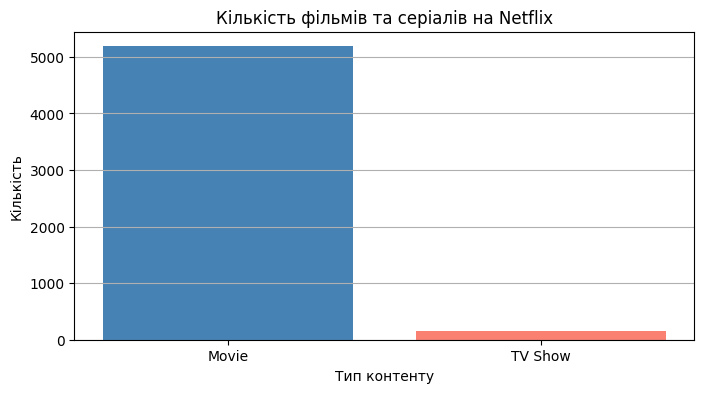

In [7]:
type_counts = df_clean['type'].value_counts()

plt.figure(figsize=(8, 4))
plt.bar(type_counts.index, type_counts.values, color=['steelblue', 'salmon'])
plt.title("Кількість фільмів та серіалів на Netflix")
plt.xlabel("Тип контенту")
plt.ylabel("Кількість")
plt.grid(axis='y')
plt.show()

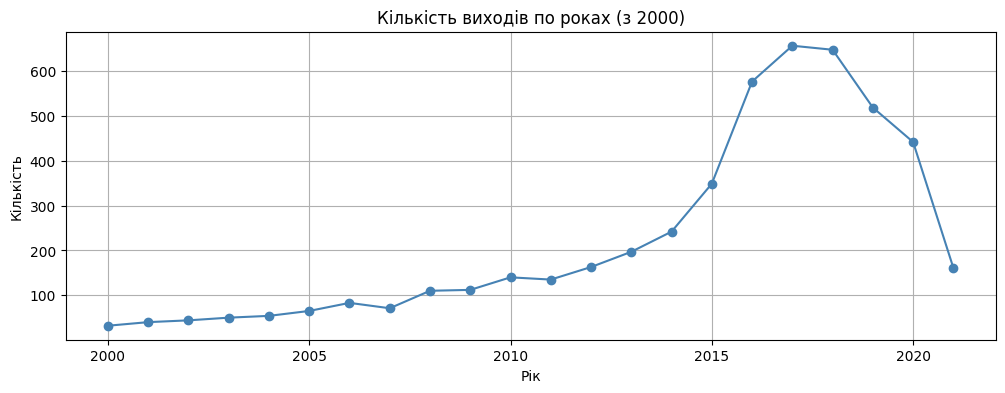

In [8]:
yearly = df_clean['release_year'].value_counts().sort_index()
yearly = yearly[yearly.index >= 2000]  # тільки з 2000 року

plt.figure(figsize=(12, 4))
plt.plot(yearly.index, yearly.values, marker='o', color='steelblue')
plt.title("Кількість виходів по роках (з 2000)")
plt.xlabel("Рік")
plt.ylabel("Кількість")
plt.grid(True)
plt.show()

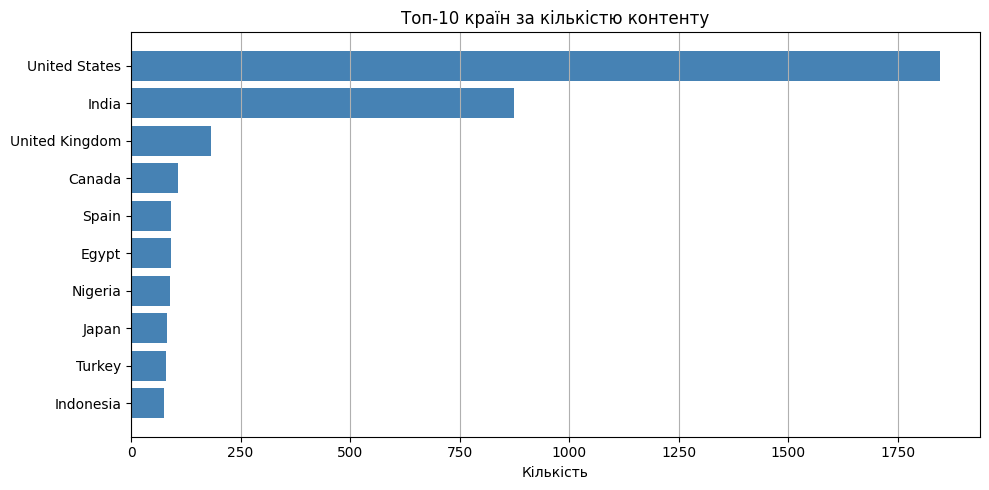

In [9]:
top_countries = df_clean['country'].value_counts().head(10)

plt.figure(figsize=(10, 5))
plt.barh(top_countries.index[::-1], top_countries.values[::-1], color='steelblue')
plt.title("Топ-10 країн за кількістю контенту")
plt.xlabel("Кількість")
plt.grid(axis='x')
plt.tight_layout()
plt.show()

# ПЗ 2

In [10]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold

# 1. Завантаження датасету
df = pd.read_csv("../data/raw/netflix_titles.csv")

# 2. Підготовка X та y
df_model = df[['type', 'release_year', 'rating', 'listed_in', 'country']].copy()
df_model = df_model.dropna(subset=['type'])
df_model['target'] = (df_model['type'] == 'Movie').astype(int)

X = df_model[['release_year', 'rating', 'listed_in', 'country']]
y = df_model['target']

print("Розподіл класів:\n", df_model['type'].value_counts())

# 3. Pipeline
num_cols = ['release_year']
cat_cols = ['rating', 'listed_in', 'country']

num_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])

cat_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preproc = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])

baseline_lr = Pipeline([
    ('prep', preproc),
    ('clf', LogisticRegression(max_iter=1000))
])

# 4. Крос-валідація ROC AUC
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_lr = cross_val_score(baseline_lr, X, y, cv=cv, scoring='roc_auc')

print("LogisticRegression ROC AUC по фолдах:", scores_lr.round(3))
print("Середнє ROC AUC:", scores_lr.mean().round(3))

Розподіл класів:
 type
Movie      6131
TV Show    2676
Name: count, dtype: int64
LogisticRegression ROC AUC по фолдах: [0.998 0.999 1.    1.    0.999]
Середнє ROC AUC: 0.999


In [11]:
from sklearn.preprocessing import FunctionTransformer, PolynomialFeatures
import numpy as np

def add_numeric_features(X_df):
    X_df = X_df.copy()

    # 1) Лог-трансформація release_year (стабілізує розподіл)
    X_df['log_year'] = np.log1p(X_df['release_year'])

    # 2) Бінінг року випуску
    bins = [0, 2000, 2010, 2015, 2018, 2025]
    labels = ['old', '2000s', '2010s', '2015s', 'recent']
    X_df['year_bin'] = pd.cut(X_df['release_year'],
                               bins=bins, labels=labels)

    # 3) Кількість жанрів (нова числова ознака)
    X_df['n_genres'] = X_df['listed_in'].str.count(',') + 1

    # 4) Взаємодія: рік * кількість жанрів
    X_df['year_genres_inter'] = X_df['release_year'] * X_df['n_genres']

    return X_df

# Застосовуємо
X_fe = add_numeric_features(X.copy())
print("Нові колонки:", ['log_year', 'year_bin', 'n_genres', 'year_genres_inter'])
print(X_fe[['release_year', 'log_year', 'year_bin',
            'n_genres', 'year_genres_inter']].head())

Нові колонки: ['log_year', 'year_bin', 'n_genres', 'year_genres_inter']
   release_year  log_year year_bin  n_genres  year_genres_inter
0          2020  7.611348   recent         1               2020
1          2021  7.611842   recent         3               6063
2          2021  7.611842   recent         3               6063
3          2021  7.611842   recent         2               4042
4          2021  7.611842   recent         3               6063


In [12]:
# Pipeline з новими числовими ознаками + поліноміальними
num_cols_fe = ['release_year', 'log_year', 'n_genres', 'year_genres_inter']
cat_cols_fe  = ['rating', 'country', 'year_bin']

preproc_fe = ColumnTransformer([
    ('poly_num', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('poly',   PolynomialFeatures(degree=2, include_bias=False)),
        ('scale',  StandardScaler())
    ]), ['release_year', 'n_genres']),          # поліноміальні для 2 колонок
    ('other_num', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale',  StandardScaler())
    ]), ['log_year', 'year_genres_inter']),
    ('cat', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('ohe',    OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), cat_cols_fe)
])

model_fe = Pipeline([
    ('feat', FunctionTransformer(add_numeric_features, validate=False)),
    ('prep', preproc_fe),
    ('clf',  LogisticRegression(max_iter=2000))
])

scores_fe = cross_val_score(model_fe, X, y, cv=cv, scoring='roc_auc')
print("\nFE (числові + поліноміальні) ROC AUC по фолдах:", scores_fe.round(3))
print("Середнє ROC AUC:", scores_fe.mean().round(3))


FE (числові + поліноміальні) ROC AUC по фолдах: [0.81  0.826 0.836 0.853 0.84 ]
Середнє ROC AUC: 0.833


In [13]:
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd

class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, cols):
        self.cols = cols
        self.freq_maps_ = {}

    def fit(self, X, y=None):
        # Конвертуємо в DataFrame якщо numpy array
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=self.cols)
        for c in self.cols:
            self.freq_maps_[c] = X[c].value_counts(normalize=True)
        return self

    def transform(self, X):
        # Конвертуємо в DataFrame якщо numpy array
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=self.cols)
        X = X.copy()
        for c in self.cols:
            X[c + '_freq'] = X[c].map(self.freq_maps_[c]).fillna(0)
        return X.drop(columns=self.cols).values

In [14]:
# One-Hot для 'rating' та 'listed_in'
# Frequency Encoding для 'country' (багато унікальних значень → freq краще)

num_cols2   = ['release_year']
cat_ohe     = ['rating', 'listed_in']
cat_freq    = ['country']

preproc_mixed = ColumnTransformer([
    ('num', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale',  StandardScaler())
    ]), num_cols2),

    ('ohe', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('ohe',    OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), cat_ohe),

    ('freq', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('freq',   FrequencyEncoder(cols=['country']))
    ]), cat_freq)
])

model_mixed = Pipeline([
    ('prep', preproc_mixed),
    ('clf',  LogisticRegression(max_iter=1000))
])

scores_mixed = cross_val_score(model_mixed, X, y, cv=cv, scoring='roc_auc')
print("OHE + Frequency Encoding ROC AUC по фолдах:", scores_mixed.round(3))
print("Середнє ROC AUC:", scores_mixed.mean().round(3))

OHE + Frequency Encoding ROC AUC по фолдах: [0.999 1.    1.    1.    1.   ]
Середнє ROC AUC: 1.0


In [15]:
from sklearn.preprocessing import FunctionTransformer

def add_time_features(X_df):
    X_df = X_df.copy()

    date = pd.to_datetime(X_df['date_added'], errors='coerce')

    X_df['added_year']      = date.dt.year
    X_df['added_month']     = date.dt.month
    X_df['added_dayofweek'] = date.dt.dayofweek

    def season(m):
        if m in [12, 1, 2]: return 'winter'
        if m in [3, 4, 5]:  return 'spring'
        if m in [6, 7, 8]:  return 'summer'
        return 'autumn'
    X_df['added_season'] = date.dt.month.map(season)

    X_df['years_to_netflix'] = X_df['added_year'] - X_df['release_year']

    return X_df

# Беремо з оригінального df і синхронізуємо індекси
X2 = df[['release_year', 'rating', 'listed_in',
         'country', 'date_added']].copy()
X2 = X2.loc[df_model.index]

# Pipeline з часовими ознаками
num_time = ['release_year', 'added_year', 'added_month',
            'added_dayofweek', 'years_to_netflix']
cat_time = ['rating', 'listed_in', 'added_season']

time_model = Pipeline([
    ('time', FunctionTransformer(add_time_features, validate=False)),
    ('prep', ColumnTransformer([
        ('num', Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale',  StandardScaler())
        ]), num_time),
        ('cat', Pipeline([
            ('impute', SimpleImputer(strategy='most_frequent')),
            ('ohe',    OneHotEncoder(handle_unknown='ignore',
                                    sparse_output=False))
        ]), cat_time)
    ])),
    ('clf', LogisticRegression(max_iter=1500))
])

scores_time = cross_val_score(time_model, X2, y, cv=cv, scoring='roc_auc')
print("Часові ознаки ROC AUC по фолдах:", scores_time.round(3))
print("Середнє ROC AUC:", scores_time.mean().round(3))

Часові ознаки ROC AUC по фолдах: [0.999 1.    1.    1.    0.999]
Середнє ROC AUC: 0.999


In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion

class TextSelector(BaseEstimator, TransformerMixin):
    def __init__(self, col):
        self.col = col
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X[self.col].fillna('')

# Беремо з оригінального df і синхронізуємо індекси
X3 = df[['release_year', 'rating', 'listed_in',
         'country', 'description']].copy()
X3 = X3.loc[df_model.index]

# Числово-категоріальна гілка
pre_num_cat = ColumnTransformer([
    ('num', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale',  StandardScaler())
    ]), ['release_year']),
    ('cat', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('ohe',    OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), ['rating', 'listed_in', 'country'])
], remainder='drop')

# Текстова гілка
text_pipe = Pipeline([
    ('select', TextSelector('description')),
    ('tfidf',  TfidfVectorizer(ngram_range=(1, 2), min_df=2))
])

# Об'єднуємо через FeatureUnion
full_feats = FeatureUnion([
    ('numcat', pre_num_cat),
    ('text',   text_pipe)
])

text_model = Pipeline([
    ('feats', full_feats),
    ('clf',   LogisticRegression(max_iter=2000))
])

scores_text = cross_val_score(text_model, X3, y, cv=cv, scoring='roc_auc')
print("TF-IDF + bigrams ROC AUC по фолдах:", scores_text.round(3))
print("Середнє ROC AUC:", scores_text.mean().round(3))

TF-IDF + bigrams ROC AUC по фолдах: [0.998 0.999 1.    1.    0.999]
Середнє ROC AUC: 0.999


In [17]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='most_frequent')
scores_dummy = cross_val_score(dummy, X, y, cv=cv, scoring='roc_auc')
print("Baseline Dummy ROC AUC по фолдах:", scores_dummy.round(3))
print("Середнє ROC AUC:", scores_dummy.mean().round(3))

Baseline Dummy ROC AUC по фолдах: [0.5 0.5 0.5 0.5 0.5]
Середнє ROC AUC: 0.5


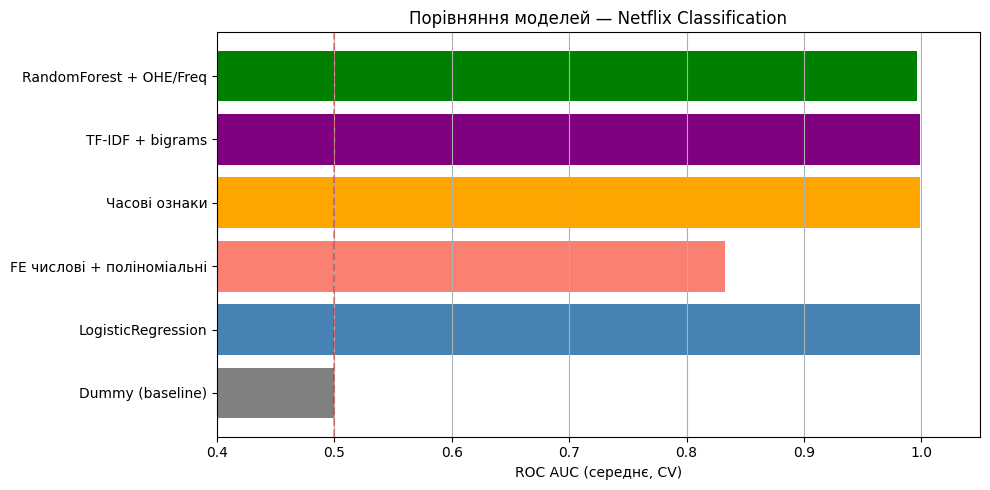

In [20]:
import matplotlib.pyplot as plt

results = {
    'Dummy (baseline)':           0.5,
    'LogisticRegression':         0.999,
    'FE числові + поліноміальні': 0.833,
    'Часові ознаки':              0.999,
    'TF-IDF + bigrams':           0.999,
    'RandomForest + OHE/Freq':    0.996
}

colors = ['gray','steelblue','salmon','orange','purple','green']

plt.figure(figsize=(10, 5))
plt.barh(list(results.keys()), list(results.values()), color=colors)
plt.xlabel('ROC AUC (середнє, CV)')
plt.title('Порівняння моделей — Netflix Classification')
plt.xlim(0.4, 1.05)
plt.axvline(x=0.5, color='red', linestyle='--', alpha=0.4, label='Dummy')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

In [19]:
from sklearn.ensemble import RandomForestClassifier

model_rf_mixed = Pipeline([
    ('prep', ColumnTransformer([
        ('num', Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale',  StandardScaler())
        ]), ['release_year']),
        ('ohe', Pipeline([
            ('impute', SimpleImputer(strategy='most_frequent')),
            ('ohe',    OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), ['rating', 'listed_in']),
        ('freq', Pipeline([
            ('impute', SimpleImputer(strategy='most_frequent')),
            ('freq',   FrequencyEncoder(cols=['country']))
        ]), ['country'])
    ])),
    ('clf', RandomForestClassifier(n_estimators=200, random_state=42))
])

scores_rf = cross_val_score(model_rf_mixed, X, y, cv=cv, scoring='roc_auc')
print("RandomForest + OHE/Frequency ROC AUC по фолдах:", scores_rf.round(3))
print("Середнє ROC AUC:", scores_rf.mean().round(3))

RandomForest + OHE/Frequency ROC AUC по фолдах: [0.996 0.995 0.998 0.998 0.996]
Середнє ROC AUC: 0.996
